<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan7/blob/main/PCD_Frekuensi_Wavelet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

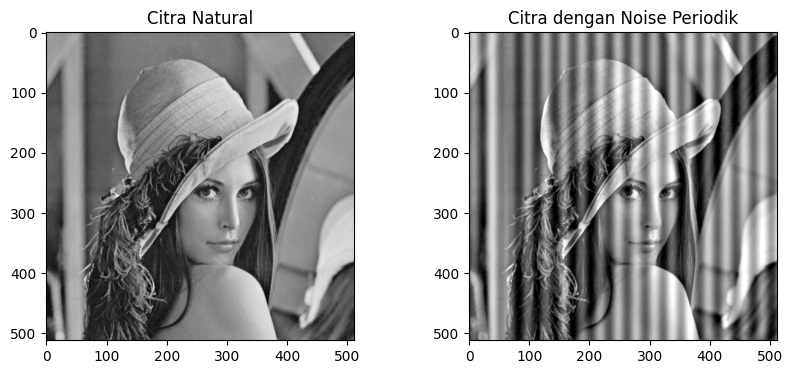

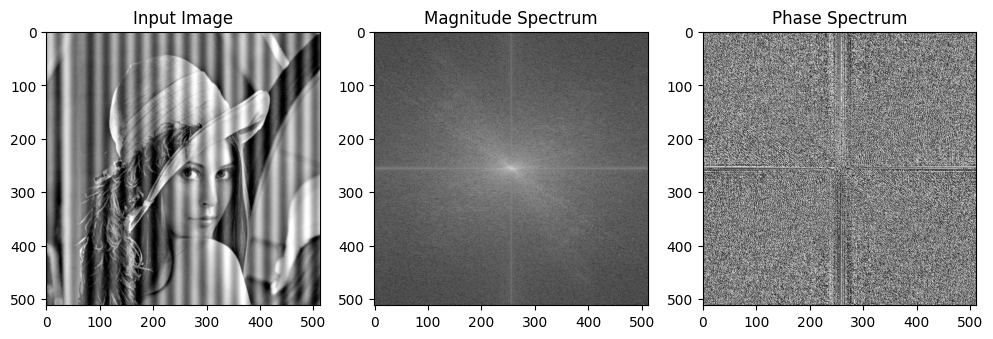

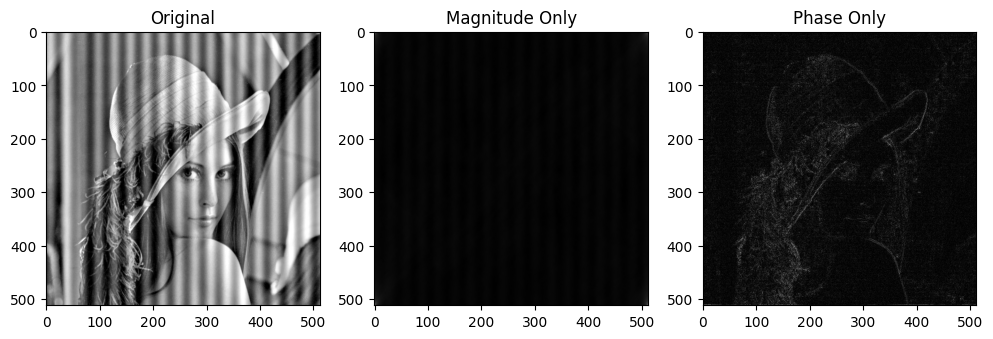

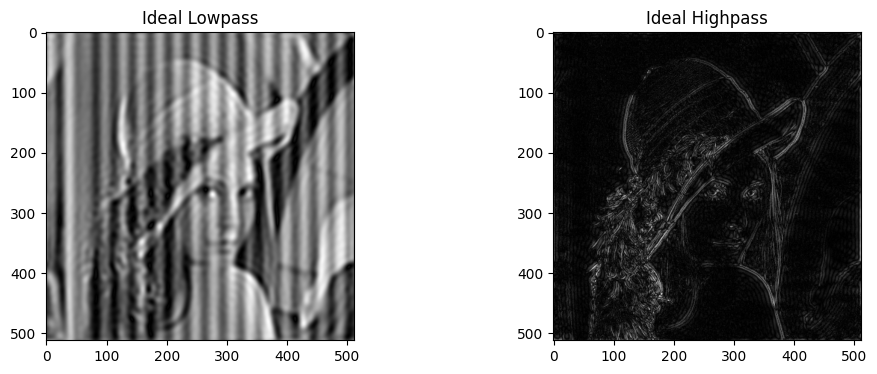

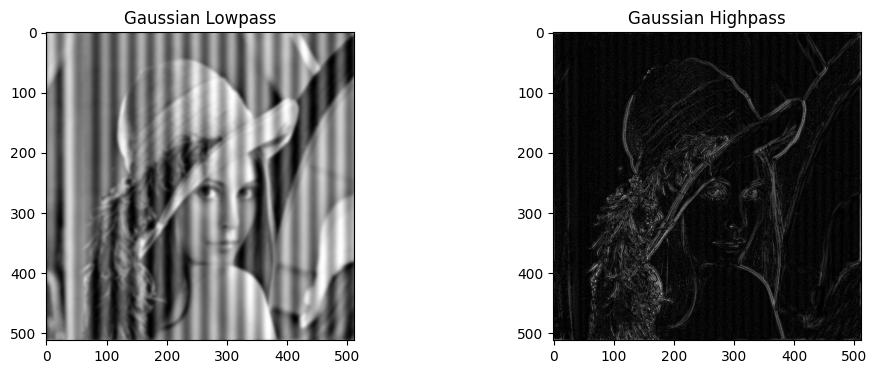

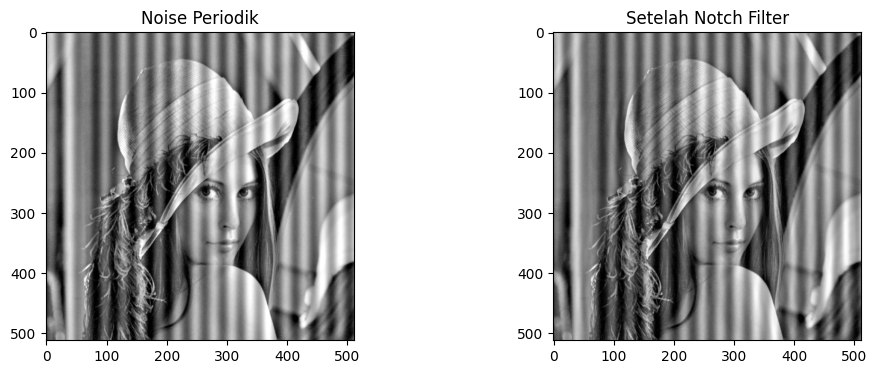

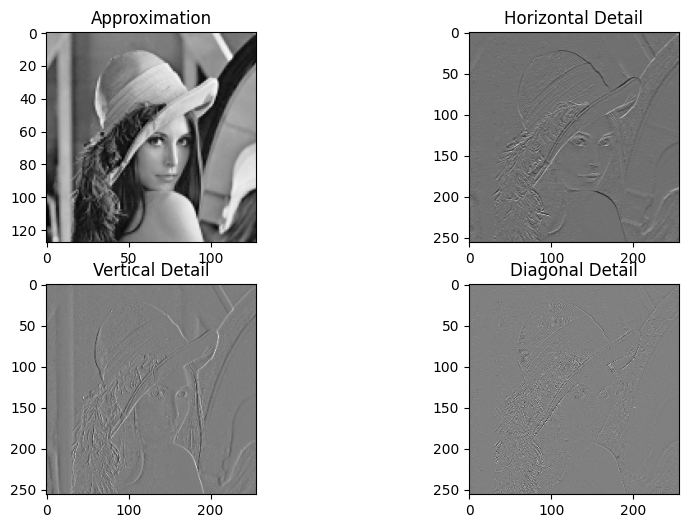

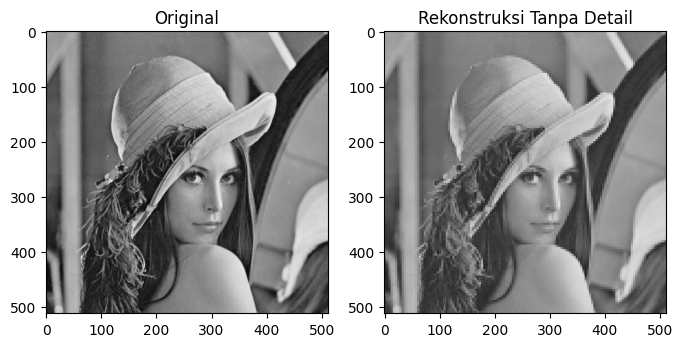

PSNR : 17.17612530190981
Waktu komputasi FFT : 0.9986772537231445 detik


In [2]:
# ===============================
# ANALISIS DAN FILTERING DOMAIN FREKUENSI
# FFT DAN WAVELET
# ===============================

!pip install pywavelets scikit-image

# ===============================
# IMPORT LIBRARY
# ===============================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
import time
from skimage.metrics import peak_signal_noise_ratio as psnr
import urllib.request

plt.rcParams['figure.figsize'] = (12,8)

# ===============================
# LOAD CITRA
# ===============================
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(url, "lena.jpg")

img = cv2.imread("lena.jpg",0).astype(np.float32)

# ===============================
# MEMBUAT NOISE PERIODIK
# ===============================
rows, cols = img.shape

x = np.arange(cols)
y = np.arange(rows)

X, Y = np.meshgrid(x,y)

periodic_noise = 50*np.sin(2*np.pi*X/30)

img_noise = img + periodic_noise
img_noise = np.clip(img_noise,0,255)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Citra Natural")
plt.imshow(img,cmap='gray')

plt.subplot(1,2,2)
plt.title("Citra dengan Noise Periodik")
plt.imshow(img_noise,cmap='gray')

plt.show()

# ===============================
# FFT DAN SPEKTRUM
# ===============================
def fft_spectrum(image):

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)

    magnitude = 20*np.log(np.abs(fshift)+1)
    phase = np.angle(fshift)

    return fshift, magnitude, phase

fshift, mag, phase = fft_spectrum(img_noise)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img_noise,cmap='gray')

plt.subplot(1,3,2)
plt.title("Magnitude Spectrum")
plt.imshow(mag,cmap='gray')

plt.subplot(1,3,3)
plt.title("Phase Spectrum")
plt.imshow(phase,cmap='gray')

plt.show()

# ===============================
# REKONSTRUKSI MAGNITUDE DAN PHASE
# ===============================
mag_only = np.abs(fshift)
phase_only = np.exp(1j*phase)

recon_mag = np.abs(np.fft.ifft2(np.fft.ifftshift(mag_only)))
recon_phase = np.abs(np.fft.ifft2(np.fft.ifftshift(phase_only)))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_noise,cmap='gray')

plt.subplot(1,3,2)
plt.title("Magnitude Only")
plt.imshow(recon_mag,cmap='gray')

plt.subplot(1,3,3)
plt.title("Phase Only")
plt.imshow(recon_phase,cmap='gray')

plt.show()

# ===============================
# IDEAL LOWPASS & HIGHPASS
# ===============================
def ideal_filter(shape, cutoff, highpass=False):

    rows, cols = shape
    crow,ccol = rows//2 , cols//2

    mask = np.zeros((rows,cols))

    for i in range(rows):
        for j in range(cols):

            d = np.sqrt((i-crow)**2 + (j-ccol)**2)

            if highpass:
                mask[i,j] = 1 if d > cutoff else 0
            else:
                mask[i,j] = 1 if d < cutoff else 0

    return mask

cutoff = 40

mask_low = ideal_filter(img.shape,cutoff)
mask_high = ideal_filter(img.shape,cutoff,True)

img_low = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask_low)))
img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask_high)))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Ideal Lowpass")
plt.imshow(img_low,cmap='gray')

plt.subplot(1,2,2)
plt.title("Ideal Highpass")
plt.imshow(img_high,cmap='gray')

plt.show()

# ===============================
# GAUSSIAN FILTER
# ===============================
def gaussian_filter(shape, cutoff, highpass=False):

    rows, cols = shape
    crow,ccol = rows//2 , cols//2

    mask = np.zeros((rows,cols))

    for i in range(rows):
        for j in range(cols):

            d = np.sqrt((i-crow)**2 + (j-ccol)**2)
            mask[i,j] = np.exp(-(d**2)/(2*(cutoff**2)))

    if highpass:
        mask = 1-mask

    return mask

mask_gauss = gaussian_filter(img.shape,40)
mask_gauss_high = gaussian_filter(img.shape,40,True)

img_gauss_low = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask_gauss)))
img_gauss_high = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask_gauss_high)))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Gaussian Lowpass")
plt.imshow(img_gauss_low,cmap='gray')

plt.subplot(1,2,2)
plt.title("Gaussian Highpass")
plt.imshow(img_gauss_high,cmap='gray')

plt.show()

# ===============================
# NOTCH FILTER
# ===============================
rows, cols = img.shape
mask = np.ones((rows,cols))

r,c = rows//2 , cols//2

mask[r-10:r+10,c+30:c+40] = 0
mask[r-10:r+10,c-40:c-30] = 0

img_notch = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask)))

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.title("Noise Periodik")
plt.imshow(img_noise,cmap='gray')

plt.subplot(1,2,2)
plt.title("Setelah Notch Filter")
plt.imshow(img_notch,cmap='gray')

plt.show()

# ===============================
# WAVELET TRANSFORM
# ===============================
coeffs = pywt.wavedec2(img, 'haar', level=2)

cA = coeffs[0]
(cH2,cV2,cD2) = coeffs[1]
(cH1,cV1,cD1) = coeffs[2]

plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Approximation")
plt.imshow(cA,cmap='gray')

plt.subplot(2,2,2)
plt.title("Horizontal Detail")
plt.imshow(cH1,cmap='gray')

plt.subplot(2,2,3)
plt.title("Vertical Detail")
plt.imshow(cV1,cmap='gray')

plt.subplot(2,2,4)
plt.title("Diagonal Detail")
plt.imshow(cD1,cmap='gray')

plt.show()

# ===============================
# REKONSTRUKSI WAVELET
# ===============================
coeffs_mod = list(coeffs)

coeffs_mod[1] = tuple([np.zeros_like(v) for v in coeffs_mod[1]])

recon = pywt.waverec2(coeffs_mod,'haar')

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img,cmap='gray')

plt.subplot(1,2,2)
plt.title("Rekonstruksi Tanpa Detail")
plt.imshow(recon,cmap='gray')

plt.show()

# ===============================
# EVALUASI
# ===============================
start = time.time()

_ = gaussian_filter(img.shape,40)

end = time.time()

psnr_value = psnr(img,img_notch,data_range=255)

print("PSNR :",psnr_value)
print("Waktu komputasi FFT :",end-start,"detik")